## Domanda Teorica

Descrivere con proprie parole (not CHAT-GPT oriented) il concetto di time series forecasting e cosa lo differenzia dai problemi ri regressione standard, fornendo esempi ed applicazioni/limiti.

La time series forecasting ha concettualmente alla base il processo di analisi determinata da una base di dati storici e attuali, per cercare di prevedere un andamento futuro. La differenza sta alla base stessa del processo di previsione. La regressione è un metodo con alla base delle inference statistiche in riferimento a un modello che poi vengono utilizzate solo in seguito, per una determinata previsione legata a un rapporto tra esse.

La time series forecasting viene usata per esempio nella finanza per cercare di prevedere il potenziale andamento del mercato e usa un ordine temporale dei dati.
La regressione viene usata per studiare la possibile relazione tra determinate variabili, sia dipendenti che indipendenti e non usa un ordine temporale dei dati.



## Fake news Detection

In [1]:
#!wget https://frenzy86.s3.eu-west-2.amazonaws.com/python/data/Fake.csv
#!wget https://frenzy86.s3.eu-west-2.amazonaws.com/python/data/True.csv
path_fake = 'https://frenzy86.s3.eu-west-2.amazonaws.com/python/data/Fake.csv'
path_true = 'https://frenzy86.s3.eu-west-2.amazonaws.com/python/data/True.csv'

In [2]:
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [3]:
df_fake = pd.read_csv(path_fake)
df_true = pd.read_csv(path_true)
df_fake["class"] = 0 #fake
df_true["class"] = 1 #real

df_marge = pd.concat([df_fake, df_true], axis =0 )
df = df_marge.drop(["title", "subject","date"], axis = 1)
df = df.sample(frac = 1).reset_index(drop=True)
df

,text,class
0,NEW YORK (Reuters) - Public approval of Presid...,1
1,WASHINGTON (Reuters) - The top Democrat on the...,1
2,Laura Loomer of Rebel Media rushed the stage a...,0
3,"Last Saturday, a bunch of well-armed militiam...",0
4,After the passing of Supreme Court Justice Ant...,0
...,...,...
44893,Amidst protests all around the country against...,0
44894,WASHINGTON (Reuters) - Vermont Senator Bernie ...,1
44895,President Trump referred to Canadian Prime Min...,0
44896,WASHINGTON (Reuters) - U.S. Senate Finance Com...,1


In [4]:
patterns = {
            r'\d+': '',             # remove digits (numeri)
            r'[^\w\s]': '',         # remove punteggiatura e simboli ...,'@!£$%
            r'\b\w{1,2}\b':'',      # remove all token less than2 characters
            r'(http|www)[^\s]+':'', # remove website
            r'\s+': ' '             # sostituisce tutti i multipli spazi con uno spazio
            }

def clean_column(df, column, patterns):
    for pattern, replacement in patterns.items():
        df[column] = df[column].str.replace(pattern, replacement)
        df[column] = df[column].str.lower() # applica il lower
    return df

#solo in preview
clean_column(df, 'text', patterns)

,text,class
0,new york (reuters) - public approval of presid...,1
1,washington (reuters) - the top democrat on the...,1
2,laura loomer of rebel media rushed the stage a...,0
3,"last saturday, a bunch of well-armed militiam...",0
4,after the passing of supreme court justice ant...,0
...,...,...
44893,amidst protests all around the country against...,0
44894,washington (reuters) - vermont senator bernie ...,1
44895,president trump referred to canadian prime min...,0
44896,washington (reuters) - u.s. senate finance com...,1


In [5]:
df['class'].value_counts()

class
0    23481
1    21417
Name: count, dtype: int64

In [6]:
df['text'].head(10)

0    new york (reuters) - public approval of presid...
1    washington (reuters) - the top democrat on the...
2    laura loomer of rebel media rushed the stage a...
3    last saturday, a bunch of well-armed  militiam...
4    after the passing of supreme court justice ant...
5    we re only two months into trump s failing pre...
6    tomi lahren literally thinks the beating of a ...
7    donald trump supporters who struggle to earn a...
8    president donald trump said his administration...
9    kitchanga, democratic republic of congo (reute...
Name: text, dtype: object

In [7]:
text_fake = list(map(str, df[df['class']==0]['text']))
text_real = list(map(str, df[df['class']==1]['text']))

text_fake = ''.join(text_fake)
text_real= ''.join(text_real)

EDA WORDCLOUD FAKE

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

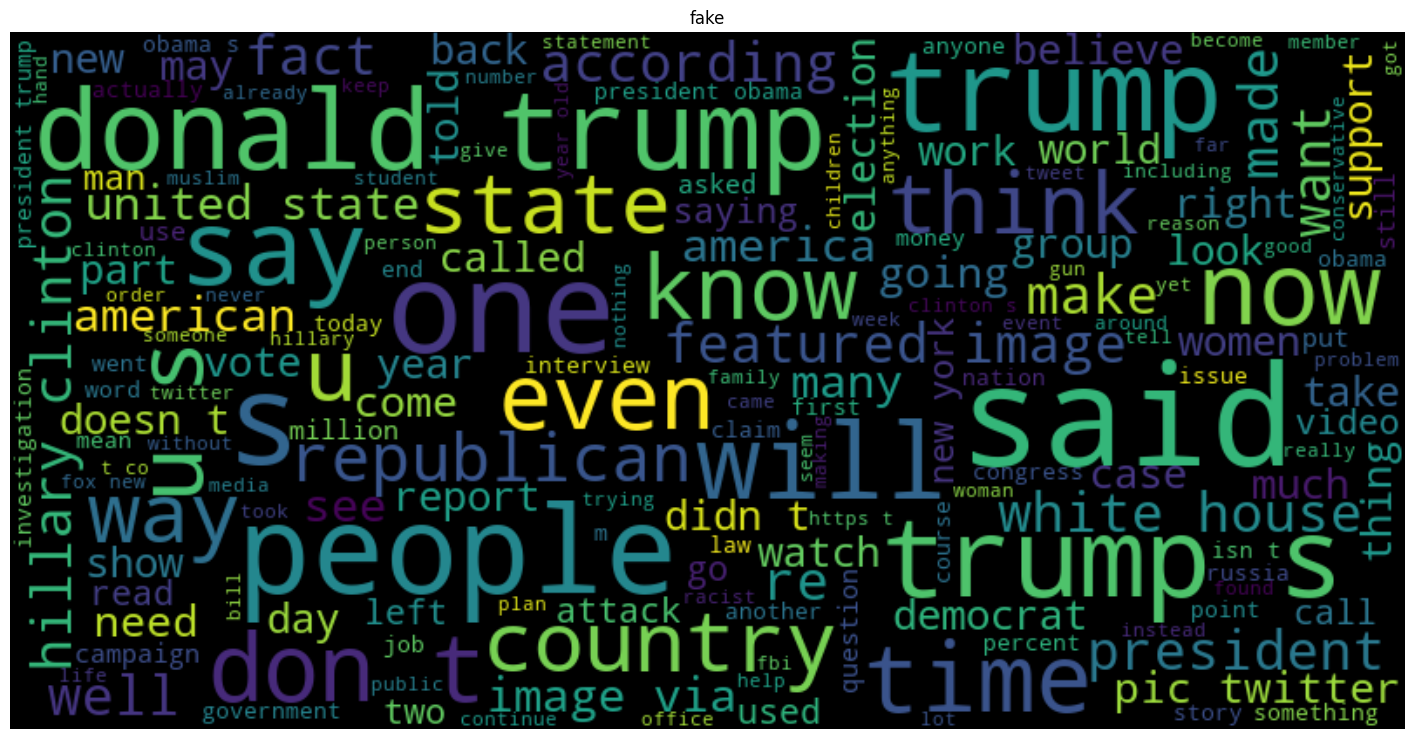

In [8]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

wordcloud = WordCloud(background_color = 'black', width = 800, height = 400,
                      max_words = 180, contour_width = 3,
                      max_font_size = 80, contour_color = 'steelblue',
                      stopwords = STOPWORDS, random_state = 667)

wordcloud.generate(text_fake)

plt.figure(figsize=(18,10))
plt.title('fake')
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis("off")

EDA WORDCLOUD REAL

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

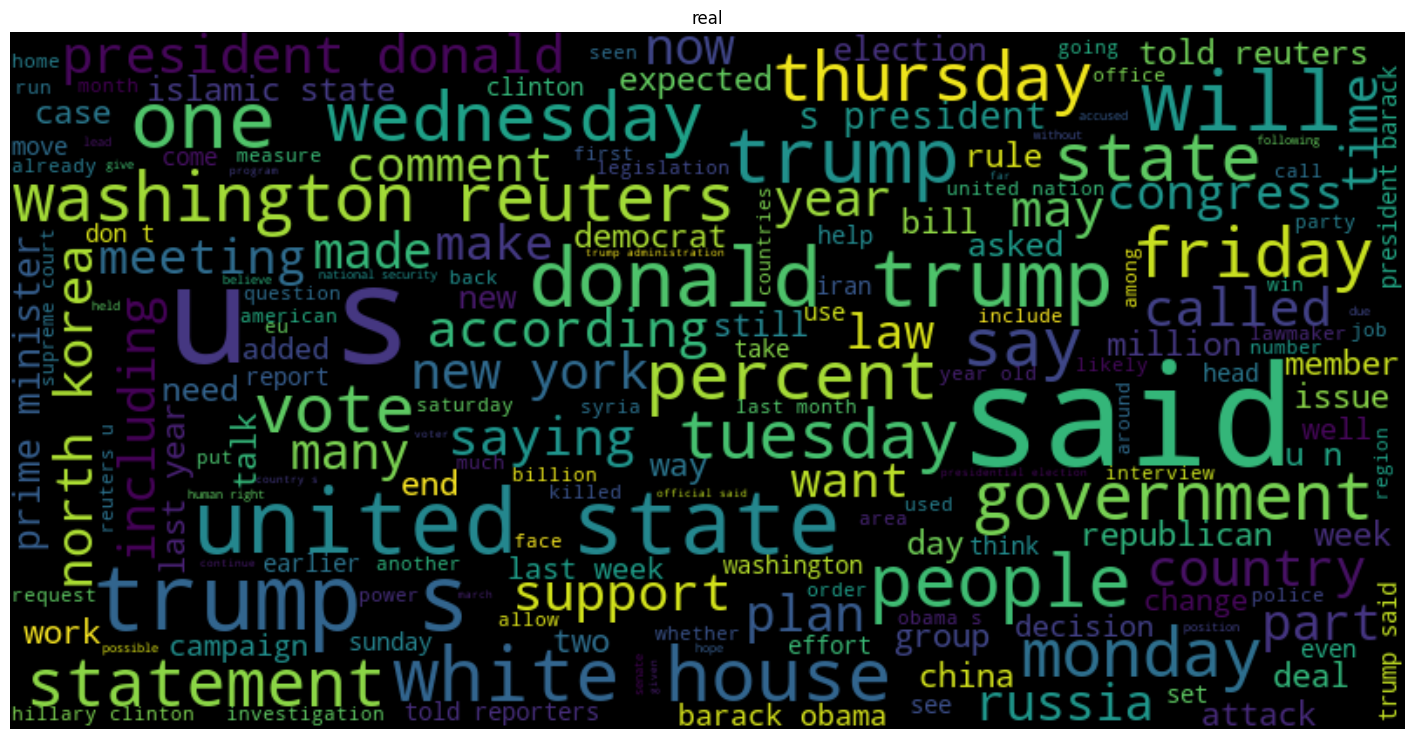

In [9]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

wordcloud = WordCloud(background_color = 'black', width = 800, height = 400,
                      max_words = 180, contour_width = 3,
                      max_font_size = 80, contour_color = 'steelblue',
                      stopwords = STOPWORDS, random_state = 667)

wordcloud.generate(text_real)

plt.figure(figsize=(18,10))
plt.title('real')
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis("off")

In [10]:
df = df[['text','class']]

In [11]:
df.isnull().sum()

text     0
class    0
dtype: int64

In [12]:
df = df.dropna()

In [13]:
X = df['text']
y = df['class']

print(X.shape)

(44898,)


VECTORIZE

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=1500, min_df=5, max_df=0.7)
#vectorizer = CountVectorizer(stop_words='english')
X_vect = vectorizer.fit_transform(X).toarray()
X_vect

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0]])

TF_IDF

In [15]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidfconverter = TfidfTransformer()
X_tfidf = tfidfconverter.fit_transform(X_vect).toarray()
X_tfidf

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.04713962,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.03945631,
        0.        ]])

SPLIT TRAINING TEST

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y,
                                                    test_size=0.3,
                                                    random_state=667
                                                    )

MODELLATION RANDOMFOREST

In [17]:
#Modellation: Randomforest
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators=1000, random_state=667,max_depth=5)
classifier.fit(X_train, y_train)

# accuracy score on the test data
y_pred = classifier.predict(X_test)
test_data_accuracy = accuracy_score(y_pred, y_test)
test_data_accuracy

0.9678544914625092

In [18]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))#, target_names=labels))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      6984
           1       0.95      0.99      0.97      6486

    accuracy                           0.97     13470
   macro avg       0.97      0.97      0.97     13470
weighted avg       0.97      0.97      0.97     13470



Text(95.72222222222221, 0.5, 'Actual')

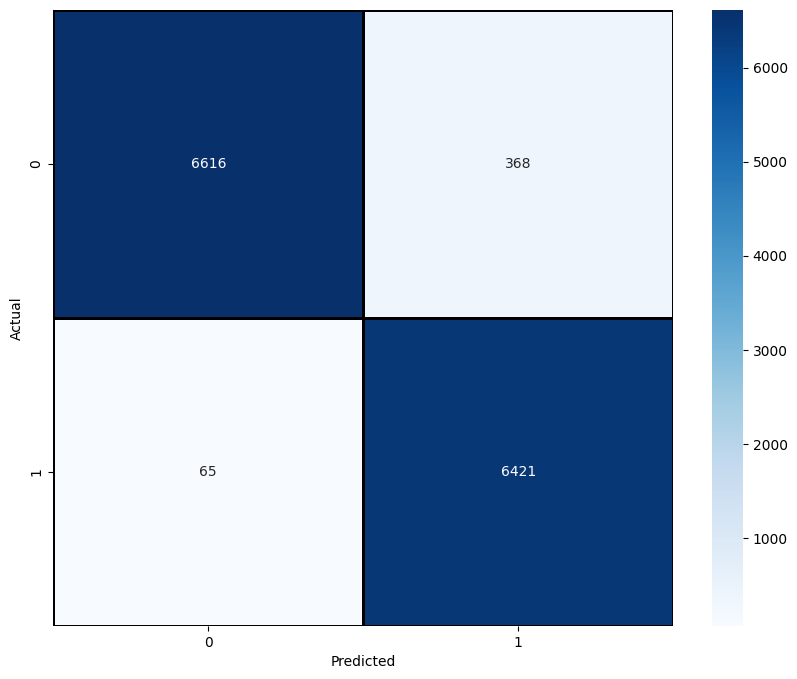

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (10,8))
sns.heatmap(cm,cmap= "Blues",
            linecolor = 'black',
            linewidth = 1,
            annot = True,
            fmt='',
            xticklabels = classifier.classes_,
            yticklabels = classifier.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")

MODELLATION MULTINOMAL

In [20]:
#Modellation: Multinomial
from sklearn.naive_bayes import MultinomialNB

classifier = MultinomialNB(alpha=0.1)
classifier.fit(X_train, y_train)

# accuracy score on the test data
y_pred = classifier.predict(X_test)
test_data_accuracy = accuracy_score(y_pred, y_test)
test_data_accuracy

0.9283593170007424

In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))#, target_names=labels))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6984
           1       0.93      0.92      0.93      6486

    accuracy                           0.93     13470
   macro avg       0.93      0.93      0.93     13470
weighted avg       0.93      0.93      0.93     13470



Text(95.72222222222221, 0.5, 'Actual')

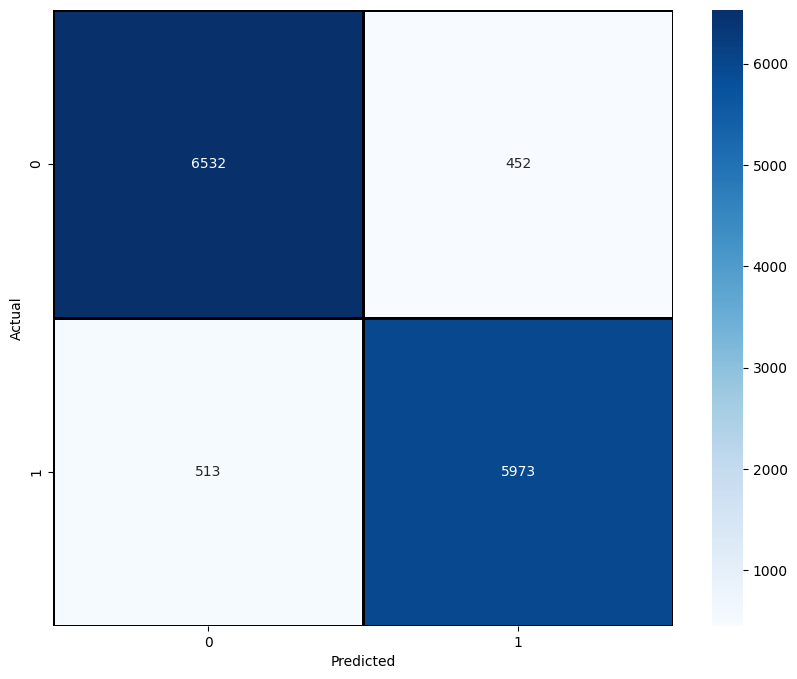

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (10,8))
sns.heatmap(cm,cmap= "Blues",
            linecolor = 'black',
            linewidth = 1,
            annot = True,
            fmt='',
            xticklabels = classifier.classes_,
            yticklabels = classifier.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")

MODELLATION SGDClassifier

In [27]:
from sklearn.linear_model import SGDClassifier

classifier = SGDClassifier(loss='log_loss', penalty='l2',alpha=1e-3, random_state=667, max_iter=5, tol=None)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
test_data_accuracy = accuracy_score(y_test,y_pred)
test_data_accuracy

0.9547141796585004

In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))#, target_names=labels))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      6984
           1       0.94      0.96      0.95      6486

    accuracy                           0.95     13470
   macro avg       0.95      0.95      0.95     13470
weighted avg       0.95      0.95      0.95     13470



Text(95.72222222222221, 0.5, 'Actual')

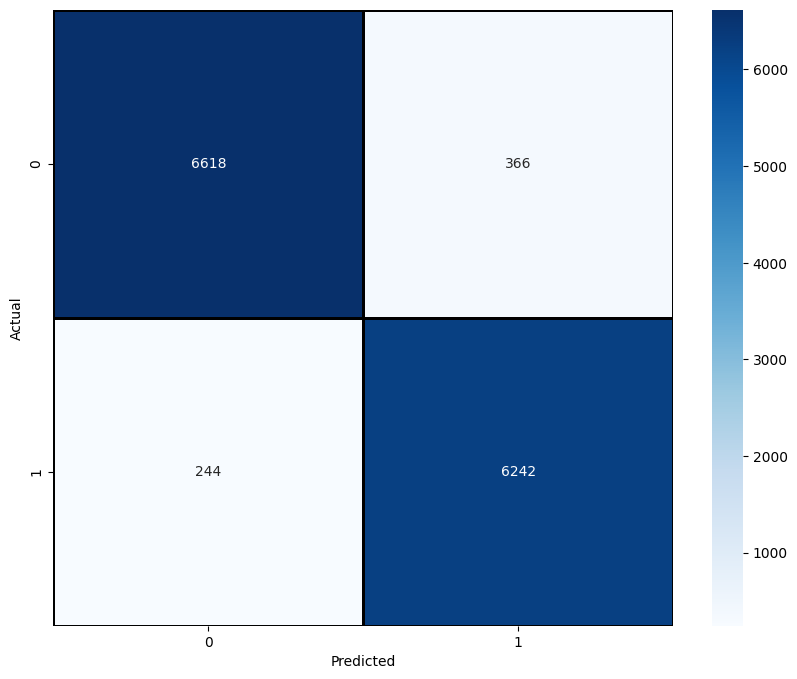

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (10,8))
sns.heatmap(cm,cmap= "Blues",
            linecolor = 'black',
            linewidth = 1,
            annot = True,
            fmt='',
            xticklabels = classifier.classes_,
            yticklabels = classifier.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")

PIPELINE FINALE

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=667
                                                    )


from sklearn.pipeline import Pipeline

bow = CountVectorizer(max_features=1500, min_df=5, max_df=0.7)
tfidf = TfidfTransformer()
clf = RandomForestClassifier(n_estimators=1000, random_state=667,max_depth=5)

pipe = Pipeline([
                ('bow',bow),
                ('tfidf',tfidf),
                ('clf',clf),
                ])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

test_data_accuracy = accuracy_score(y_test,y_pred)
print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  0.9655530809205642


In [31]:
from sklearn.metrics import classification_report
#labels = ['class1', 'class2']
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97      6984
           1       0.94      0.99      0.97      6486

    accuracy                           0.97     13470
   macro avg       0.97      0.97      0.97     13470
weighted avg       0.97      0.97      0.97     13470



Text(95.72222222222221, 0.5, 'Actual')

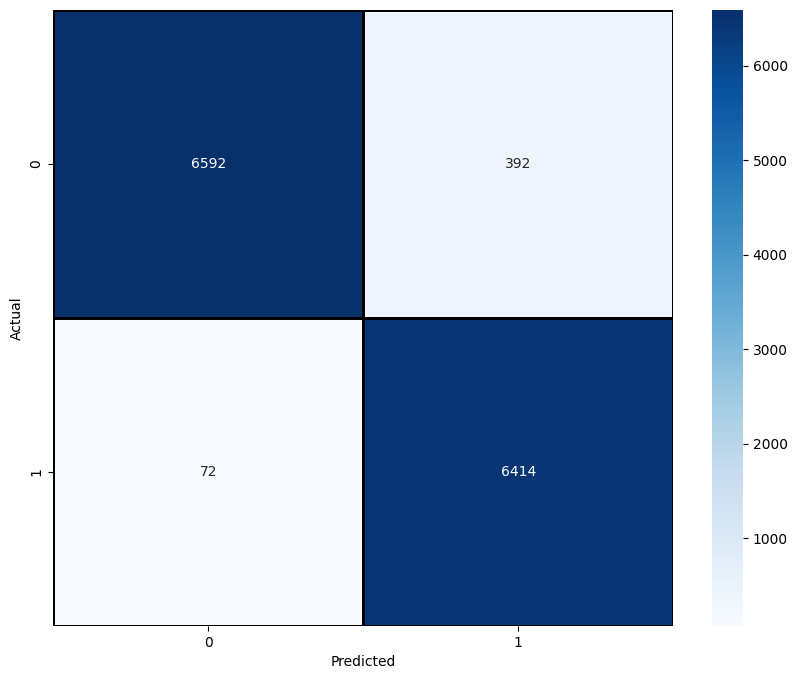

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (10,8))
sns.heatmap(cm,cmap= "Blues",
            linecolor = 'black',
            linewidth = 1,
            annot = True,
            fmt='',
            xticklabels = classifier.classes_,
            yticklabels = classifier.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")

CROSS VALIDATION

In [33]:
import numpy as np
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipe, X, y, scoring = 'f1_micro', cv = 8)

print(f'scores={scores}')
print(f'mean={np.mean(scores)}')
print(f'std={np.std(scores)}')

scores=[0.96757527 0.96917869 0.96970777 0.9657876  0.96899501 0.96311475
 0.96026372 0.96347113]
mean=0.9660117437196184
std=0.003220479966030887


In [34]:
import joblib
joblib.dump(pipe,'real_fake.pkl')

['real_fake.pkl']

In [35]:
import joblib

uploaded_model = joblib.load('real_fake.pkl')
pred = uploaded_model.predict([df.iloc[1][0]]) #
pred[0]

np.int64(1)